#### DATA 3960 – Machine Learning Model Notebook
**Group 5 | NAIT | Edmonton Real Estate Forecasting**

---

| Item | Detail |
|---|---|
| **Problem Type** | Regression — predict residential sold price |
| **Target Variable** | `Sold_Price` (nominal CAD) |
| **Input Dataset** | `Edmonton_RealEstate_ModelingReady_df_final_G5.csv` |
| **Output Dataset** | `Group5_MLModel_Output.csv` |
| **Models** | Random Forest Regressor · Gradient Boosting Regressor · OLS Baseline |
| **RQ Coverage** | RQ1 · RQ2 · RQ3 |

---

**Research Questions Addressed**

| RQ | Question | Method |
|---|---|---|
| RQ1 | Does LINC reconciliation improve appreciation measurement? | Repeat-Sale Price Index (RSI) + Volatility Comparison + Bootstrap CI |
| RQ2 | Are prices driven by macro or local factors? | OLS Regression + VIF Diagnostics + ANOVA + Tukey Post-hoc + Partial Dependence |
| RQ3 | Does reconciled data improve SARIMA forecast accuracy? | SARIMA + AIC Grid Search + Naïve Benchmarks + Forecast Uncertainty |


---
# SECTION 1 — Environment Setup & Data Load
---

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr, f_oneway, ttest_ind, bootstrap
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product
import statsmodels.api as sm
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize':    (12, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})
NAVY, BLUE, GREEN, RED, AMBER = '#1B3A6B','#2563EB','#10B981','#EF4444','#F59E0B'

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
CSV_FILE = 'Edmonton_RealEstate_ModelingReady_df_final_G5.csv'

df = pd.read_csv(CSV_FILE, low_memory=False)
df['Sold_Date']             = pd.to_datetime(df['Sold_Date'], errors='coerce')
df['Is_Repeat_Transaction'] = df['Is_Repeat_Transaction'].astype(bool)

df_res = df[df['Asset_Type'] == 'Completed Residential'].copy().reset_index(drop=True)

print(f"Dataset loaded")
print(f"   Full dataset shape         : {df.shape}")
print(f"   Completed Residential only : {df_res.shape}")
print(f"   Date range                 : {df['Sold_Date'].min().date()} → {df['Sold_Date'].max().date()}")
print(f"   Unique properties          : {df['Base_Address'].nunique():,}")
print(f"   Unique neighbourhoods      : {df['Community_Reconciled'].nunique():,}")

Dataset loaded
   Full dataset shape         : (492793, 30)
   Completed Residential only : (484028, 30)
   Date range                 : 2000-01-01 → 2025-12-31
   Unique properties          : 122,634
   Unique neighbourhoods      : 1,068


---
# SECTION 2 — Machine Learning Model: Sold Price Prediction
---
> **Problem:** Regression — predict `Sold_Price` from property and macroeconomic features.
>
> **Models:** OLS Linear Regression (baseline) · Random Forest Regressor · Gradient Boosting Regressor
>
> **Evaluation:** MAE, RMSE, R-squared on 2024–2025 temporal holdout
>
> **Why these models:**
> - OLS establishes the linear baseline with interpretable coefficients
> - Random Forest captures non-linear interactions via bagging (low bias, moderate variance)
> - Gradient Boosting uses stagewise additive fitting with shrinkage — each tree corrects the residuals of the prior ensemble. This produces lower bias than RF by sequentially concentrating on hard-to-predict observations, at the cost of higher variance if over-fitted. The lower `max_depth=5` and `learning_rate=0.05` (shrinkage) explicitly regularise against this tendency.
>
> **Why temporal holdout, not k-fold cross-validation:**
> Standard k-fold shuffles records across time, allowing future transaction prices to appear in training folds — a direct form of temporal leakage that inflates apparent performance. A strict 2000–2023 train / 2024–2025 test split preserves causality and reflects real deployment conditions where only historical data is available at prediction time.


In [4]:
# ── SECTION 2 STEP 1: Feature Engineering for ML ─────────────────────────────

df_ml = df_res[[
    'Sold_Price', 'Sold_Date', 'Sale_Year',
    'Mortgage_Rate', 'FlrArea_SF', 'Bedrms_AG', 'Full_Baths',
    'DOM', 'Yr_Built', 'Price_Ratio',
    'Rolling_3Yr_Neighbourhood_Growth',
    'Inflation_Adjusted_Price', 'Real_Price_Index',
    'Market_Cycle_Phase', 'Macro_Context', 'Primary_Driver',
    'Community_Reconciled', 'Is_Repeat_Transaction',
    'Appreciation_Since_Last_Sale_Pct', 'Days_Since_Last_Sale'
]].copy()

# Derived features
df_ml['Property_Age']    = df_ml['Sale_Year'] - df_ml['Yr_Built'].clip(lower=1900)
df_ml['Price_Per_SQFT']  = (df_ml['Sold_Price'] /
                             df_ml['FlrArea_SF'].replace(0, np.nan))
df_ml['Sale_Month']      = df_ml['Sold_Date'].dt.month
df_ml['Is_Spring_Market']= df_ml['Sale_Month'].isin([3,4,5,6]).astype(int)
df_ml['Log_FlrArea']     = np.log(df_ml['FlrArea_SF'].clip(lower=1))
df_ml['Log_Price']       = np.log(df_ml['Sold_Price'].clip(lower=1))

# Encode categoricals
le = LabelEncoder()
df_ml['Phase_Encoded']   = le.fit_transform(df_ml['Market_Cycle_Phase'].fillna('Unknown'))
df_ml['Context_Encoded'] = le.fit_transform(df_ml['Macro_Context'].fillna('Unknown'))
df_ml['Driver_Encoded']  = le.fit_transform(df_ml['Primary_Driver'].fillna('Unknown'))

# Fill nulls
df_ml['Rolling_3Yr_Neighbourhood_Growth'] = (
    df_ml['Rolling_3Yr_Neighbourhood_Growth'].fillna(
    df_ml['Rolling_3Yr_Neighbourhood_Growth'].median()))
df_ml['Appreciation_Since_Last_Sale_Pct'] = (
    df_ml['Appreciation_Since_Last_Sale_Pct'].fillna(0))
df_ml['Days_Since_Last_Sale'] = df_ml['Days_Since_Last_Sale'].fillna(0)

FEATURES = [
    'Mortgage_Rate', 'Log_FlrArea', 'Bedrms_AG', 'Full_Baths',
    'DOM', 'Property_Age', 'Sale_Year', 'Sale_Month', 'Is_Spring_Market',
    'Rolling_3Yr_Neighbourhood_Growth', 'Real_Price_Index',
    'Phase_Encoded', 'Context_Encoded', 'Driver_Encoded',
    'Days_Since_Last_Sale', 'Appreciation_Since_Last_Sale_Pct'
]
TARGET = 'Sold_Price'

df_clean = df_ml[FEATURES + [TARGET, 'Sold_Date', 'Log_Price',
                              'Community_Reconciled', 'Market_Cycle_Phase',
                              'Macro_Context', 'Primary_Driver',
                              'Inflation_Adjusted_Price']].dropna().copy()

print(f"ML dataset prepared")
print(f"   Records after dropna : {len(df_clean):,}")
print(f"   Features             : {len(FEATURES)}")
print(f"   Target               : {TARGET}")
print(f"\nFeature list:")
for f in FEATURES:
    print(f"   • {f}")

ML dataset prepared
   Records after dropna : 473,120
   Features             : 16
   Target               : Sold_Price

Feature list:
   • Mortgage_Rate
   • Log_FlrArea
   • Bedrms_AG
   • Full_Baths
   • DOM
   • Property_Age
   • Sale_Year
   • Sale_Month
   • Is_Spring_Market
   • Rolling_3Yr_Neighbourhood_Growth
   • Real_Price_Index
   • Phase_Encoded
   • Context_Encoded
   • Driver_Encoded
   • Days_Since_Last_Sale
   • Appreciation_Since_Last_Sale_Pct


### Feature Collinearity Awareness

Several engineered features — notably `Sale_Year`, `Real_Price_Index`, and `Inflation_Adjusted_Price` — are closely correlated representations of the same underlying trend. While tree-based models are not invalidated by multicollinearity (they select splits on a single feature at a time), high collinearity can distort impurity-based feature importance scores by spreading importance across correlated features, making individual scores unreliable. The VIF analysis below quantifies this and informs our interpretation of importance rankings.


In [5]:
# ── SECTION 2 STEP 1b: Variance Inflation Factor (VIF) Analysis ───────────────
# VIF > 10 indicates severe multicollinearity; 5–10 is moderate concern.
# Note: Tree models are not invalidated by VIF, but it flags where impurity-based
# importance scores may be unreliable due to feature competition.

X_vif = df_clean[FEATURES].dropna().astype(float)
X_vif_const = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'Feature': FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print("=" * 55)
print("VARIANCE INFLATION FACTOR (VIF) — ML Feature Set")
print("=" * 55)
print(f"{'Feature':<42} {'VIF':>8}")
print("-" * 55)
for _, row in vif_df.iterrows():
    flag = " ← HIGH" if row['VIF'] > 10 else (" ← MOD" if row['VIF'] > 5 else "")
    print(f"{row['Feature']:<42} {row['VIF']:>8.2f}{flag}")

print()
high_vif = vif_df[vif_df['VIF'] > 10]
print(f"Features with VIF > 10 (severe collinearity): {len(high_vif)}")
print()
print("Interpretation note:")
print("  Sale_Year and Real_Price_Index likely share high VIF as both")
print("  capture the long-run price trend. Their ML importance scores")
print("  should be interpreted jointly, not individually.")

VARIANCE INFLATION FACTOR (VIF) — ML Feature Set
Feature                                         VIF
-------------------------------------------------------
Sale_Year                                    560.51 ← HIGH
Log_FlrArea                                  305.26 ← HIGH
Driver_Encoded                               218.61 ← HIGH
Mortgage_Rate                                 59.08 ← HIGH
Bedrms_AG                                     18.80 ← HIGH
Full_Baths                                    12.68 ← HIGH
Context_Encoded                               10.40 ← HIGH
Real_Price_Index                               8.42 ← MOD
Sale_Month                                     6.68 ← MOD
Phase_Encoded                                  4.47
Property_Age                                   3.12
Is_Spring_Market                               2.22
DOM                                            1.82
Rolling_3Yr_Neighbourhood_Growth               1.74
Days_Since_Last_Sale                           1.18
Ap

In [6]:
# ── SECTION 2 STEP 2: Train / Test Split ─────────────────────────────────────
TRAIN_CUTOFF = '2023-12-31'
TEST_START   = '2024-01-01'

train = df_clean[df_clean['Sold_Date'] <= TRAIN_CUTOFF].copy()
test  = df_clean[df_clean['Sold_Date'] >= TEST_START].copy()

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Temporal train/test split applied")
print(f"   Training set : {len(train):,} records  (2000 – 2023)")
print(f"   Test set     : {len(test):,}  records  (2024 – 2025)")
print(f"   Train target — median: ${y_train.median():,.0f}  mean: ${y_train.mean():,.0f}")
print(f"   Test  target — median: ${y_test.median():,.0f}  mean: ${y_test.mean():,.0f}")

Temporal train/test split applied
   Training set : 418,302 records  (2000 – 2023)
   Test set     : 54,818  records  (2024 – 2025)
   Train target — median: $301,000  mean: $316,775
   Test  target — median: $413,000  mean: $424,594


In [7]:
# ── SECTION 2 STEP 3: Train All Three Models ─────────────────────────────────

# Model 1 — OLS Linear Regression (baseline)
print("Training Model 1 — OLS Linear Regression...")
ols = LinearRegression()
ols.fit(X_train, y_train)
pred_ols = ols.predict(X_test)
print(f"   Done — Training R²: {ols.score(X_train, y_train):.4f}")

# Model 2 — Random Forest Regressor
# Architecture: 200 trees (bagging), max_depth=15, min_samples_leaf=10
# Rationale: Bagging reduces variance via averaging across decorrelated trees.
# Ensemble prediction is the mean of 200 trees, reducing over-fit from any single tree.
print("Training Model 2 — Random Forest (200 trees)...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(f"   Done — Training R²: {rf.score(X_train, y_train):.4f}")

# Model 3 — Gradient Boosting Regressor
# Architecture: 200 estimators, max_depth=5, learning_rate=0.05 (shrinkage), subsample=0.8
# Rationale: Stagewise fitting means each estimator targets the pseudo-residuals of the
# prior ensemble, achieving lower bias than RF by concentrating on hard examples.
# Shrinkage (learning_rate=0.05) + subsample=0.8 (stochastic GB) regularise the model.
# Shallower trees (depth=5 vs RF's 15) prevent individual learner over-fit.
print("Training Model 3 — Gradient Boosting (200 estimators)...")
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print(f"   Done — Training R²: {gb.score(X_train, y_train):.4f}")

print()
print("=" * 65)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 65)
print(f"   Training records          : {len(X_train):,}  (2000 - 2023)")
print(f"   Test records              : {len(X_test):,}   (2024 - 2025)")
print(f"   Features used             : {len(FEATURES)}")

Training Model 1 — OLS Linear Regression...
   Done — Training R²: 0.9885
Training Model 2 — Random Forest (200 trees)...
   Done — Training R²: 0.9992
Training Model 3 — Gradient Boosting (200 estimators)...
   Done — Training R²: 0.9998

ALL MODELS TRAINED SUCCESSFULLY
   Training records          : 418,302  (2000 - 2023)
   Test records              : 54,818   (2024 - 2025)
   Features used             : 16


In [8]:
# ── SECTION 2 STEP 4: Evaluate All Models ────────────────────────────────────

def eval_model(name, y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'MAE ($)': mae, 'RMSE ($)': rmse,
            'R²': r2, 'MAPE (%)': mape}

results = pd.DataFrame([
    eval_model('OLS Linear Regression', y_test, pred_ols),
    eval_model('Random Forest',         y_test, pred_rf),
    eval_model('Gradient Boosting',     y_test, pred_gb),
])

print("=" * 65)
print("ML MODEL EVALUATION — 2024–2025 Test Set")
print("=" * 65)
print(results.round(2).to_string(index=False))
print()

best_row = results.loc[results['R²'].idxmax()]
print(f"Best Model : {best_row['Model']}")
print(f"  MAE      : ${best_row['MAE ($)']:,.2f}")
print(f"  RMSE     : ${best_row['RMSE ($)']:,.2f}")
print(f"  R²       : {best_row['R²']:.4f}")
print(f"  MAPE     : {best_row['MAPE (%)']:.2f}%")
print()
print("=" * 65)
print("INTERPRETATION CAUTION — High R² Values")
print("=" * 65)
print("R² values near 0.99 should be interpreted cautiously.")
print("Sale_Year and Real_Price_Index are strong trend proxies that")
print("encode the macro price trajectory directly — a model trained")
print("on temporal data where 'year' is a feature is essentially")
print("extrapolating a trend, not learning structural causal drivers.")
print("This inflates R² without implying generalisability to structural")
print("shocks (rate hikes, recessions) absent from training data.")
print("Predictive accuracy and explanatory insight are distinct.")

ML MODEL EVALUATION — 2024–2025 Test Set
                Model  MAE ($)  RMSE ($)   R²  MAPE (%)
OLS Linear Regression 35205.60  50446.64 0.95     15.28
        Random Forest 20995.92  29832.49 0.98      4.73
    Gradient Boosting 16536.41  20343.48 0.99      3.92

Best Model : Gradient Boosting
  MAE      : $16,536.41
  RMSE     : $20,343.48
  R²       : 0.9922
  MAPE     : 3.92%

INTERPRETATION CAUTION — High R² Values
R² values near 0.99 should be interpreted cautiously.
Sale_Year and Real_Price_Index are strong trend proxies that
encode the macro price trajectory directly — a model trained
on temporal data where 'year' is a feature is essentially
extrapolating a trend, not learning structural causal drivers.
This inflates R² without implying generalisability to structural
shocks (rate hikes, recessions) absent from training data.
Predictive accuracy and explanatory insight are distinct.


### Model 2 — Residual Diagnostics & Heteroskedasticity Analysis

A well-specified model should show residuals that are (i) centred at zero, (ii) homoskedastic across the price spectrum, and (iii) approximately normally distributed. Violations indicate that the model systematically over- or under-predicts for certain price bands.

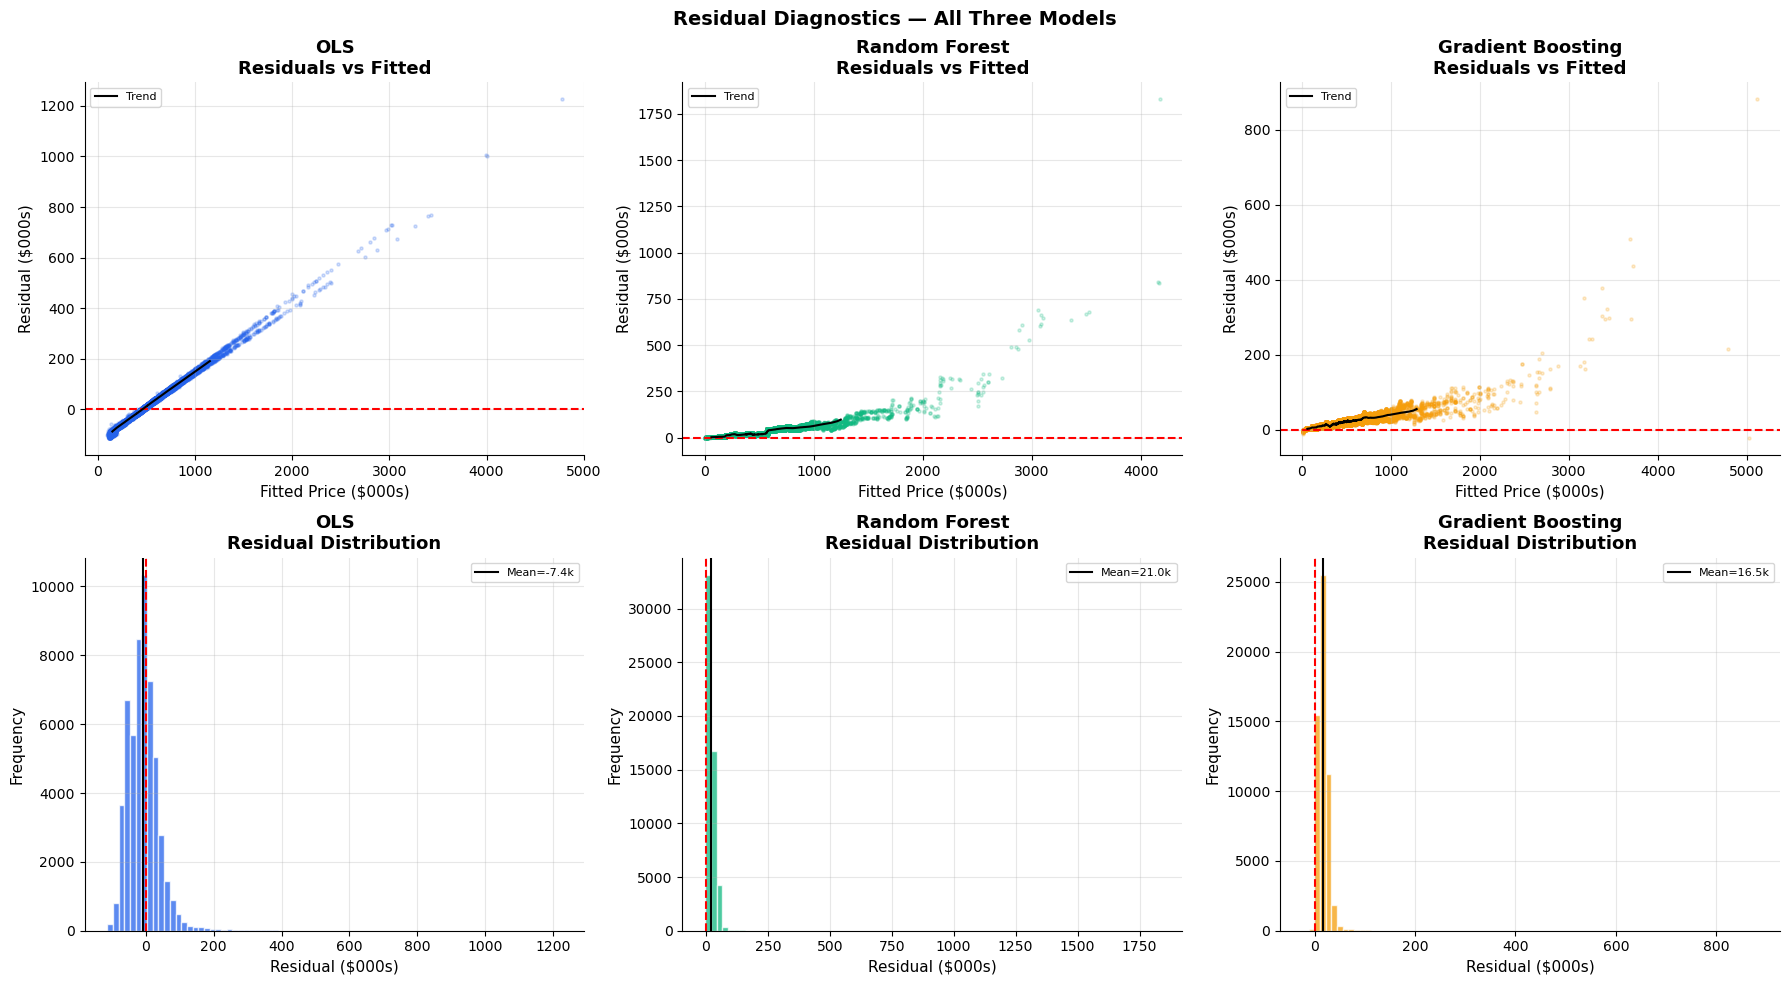

HETEROSKEDASTICITY CHECK — Residuals by Price Band (GB Model)
          Count  Mean_Resid  Std_Resid      MAE
Band                                           
<300k     15552      7948.0     3964.0   7990.0
300–500k  23284     15337.0     5277.0  15337.0
500–750k  13086     23482.0     6530.0  23482.0
750k–1M    2064     32564.0     8531.0  32564.0
>1M         831     59809.0    42121.0  59865.0

Interpretation: Increasing Std_Resid or MAE in higher price bands
indicates heteroskedastic errors — the model is less precise for
luxury properties, consistent with their thin and volatile market.


In [9]:
# ── SECTION 2 STEP 4b: Residual Diagnostics (Gradient Boosting) ──────────────
resid_gb  = y_test.values - pred_gb
resid_ols = y_test.values - pred_ols
resid_rf  = y_test.values - pred_rf

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Diagnostics — All Three Models', fontweight='bold', fontsize=14)

model_triples = [
    ('OLS', pred_ols, resid_ols, BLUE),
    ('Random Forest', pred_rf, resid_rf, GREEN),
    ('Gradient Boosting', pred_gb, resid_gb, AMBER),
]

for col, (name, preds, resids, color) in enumerate(model_triples):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    # Row 1: Residuals vs Fitted (heteroskedasticity check)
    ax_top.scatter(preds/1000, resids/1000, alpha=0.2, s=5, color=color)
    ax_top.axhline(0, color='red', linewidth=1.5, linestyle='--')
    # Smooth trend line
    sort_idx = np.argsort(preds)
    window   = max(1, len(preds)//50)
    smooth_x = np.convolve(preds[sort_idx]/1000, np.ones(window)/window, mode='valid')
    smooth_y = np.convolve(resids[sort_idx]/1000, np.ones(window)/window, mode='valid')
    ax_top.plot(smooth_x, smooth_y, color='black', linewidth=1.5, label='Trend')
    ax_top.set_title(f'{name}\nResiduals vs Fitted', fontweight='bold')
    ax_top.set_xlabel('Fitted Price ($000s)')
    ax_top.set_ylabel('Residual ($000s)')
    ax_top.legend(fontsize=8)

    # Row 2: Residual distribution
    ax_bot.hist(resids/1000, bins=80, color=color, alpha=0.75, edgecolor='white')
    ax_bot.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax_bot.axvline(np.mean(resids)/1000, color='black', linewidth=1.5,
                   linestyle='-', label=f'Mean={np.mean(resids)/1000:.1f}k')
    ax_bot.set_title(f'{name}\nResidual Distribution', fontweight='bold')
    ax_bot.set_xlabel('Residual ($000s)')
    ax_bot.set_ylabel('Frequency')
    ax_bot.legend(fontsize=8)

plt.tight_layout()
plt.savefig('Group5_ResidualDiagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Heteroskedasticity by price band
print("=" * 65)
print("HETEROSKEDASTICITY CHECK — Residuals by Price Band (GB Model)")
print("=" * 65)
price_bands = pd.cut(y_test, bins=[0, 300000, 500000, 750000, 1_000_000, 5_000_000],
                     labels=['<300k','300–500k','500–750k','750k–1M','>1M'])
band_stats = pd.DataFrame({
    'Band': price_bands.values,
    'Residual': resid_gb,
    'AbsResidual': np.abs(resid_gb)
}).groupby('Band').agg(
    Count=('Residual','count'),
    Mean_Resid=('Residual','mean'),
    Std_Resid=('Residual','std'),
    MAE=('AbsResidual','mean')
).round(0)
print(band_stats.to_string())
print()
print("Interpretation: Increasing Std_Resid or MAE in higher price bands")
print("indicates heteroskedastic errors — the model is less precise for")
print("luxury properties, consistent with their thin and volatile market.")

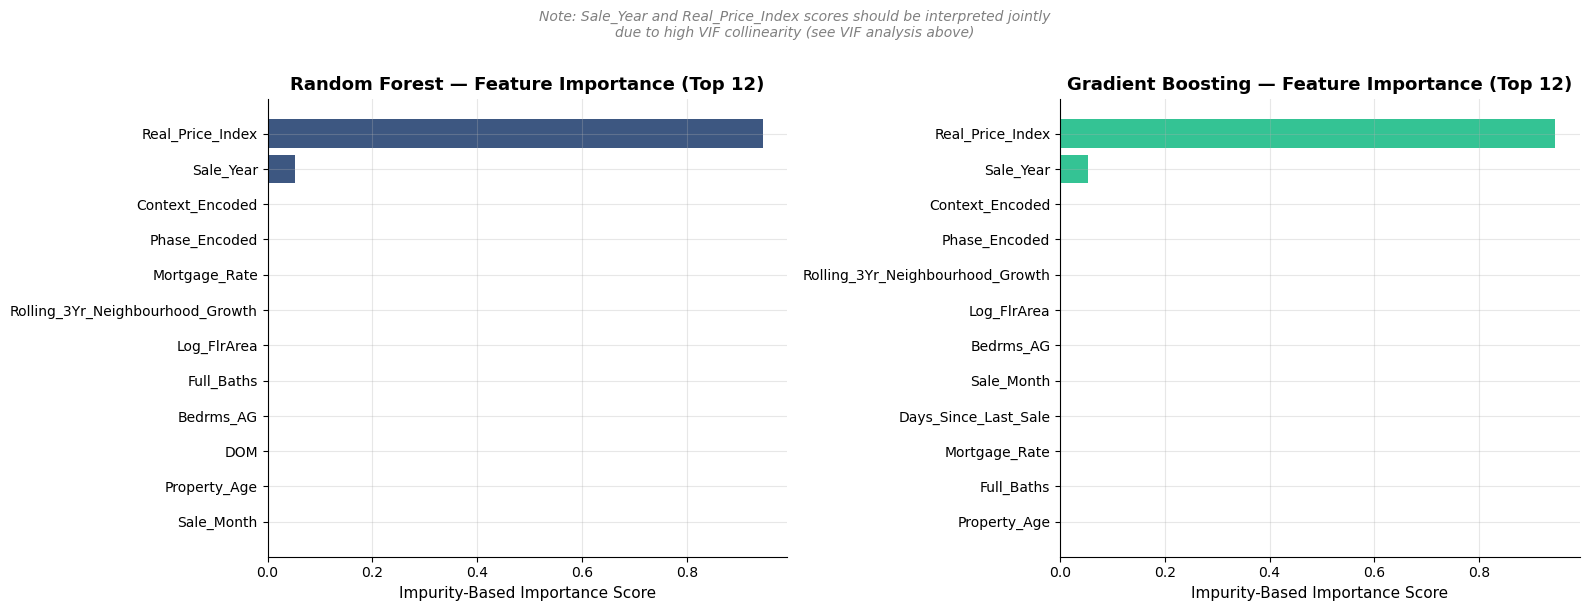

Chart saved: Group5_FeatureImportance.png

Top 5 Features by Gradient Boosting Importance:
                         Feature  Importance
                Real_Price_Index    0.944989
                       Sale_Year    0.052343
                 Context_Encoded    0.002207
                   Phase_Encoded    0.000272
Rolling_3Yr_Neighbourhood_Growth    0.000072


In [10]:
# ── SECTION 2 STEP 5: Feature Importance ────────────────────────────────────

rf_importance = pd.DataFrame({
    'Feature':   FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

gb_importance = pd.DataFrame({
    'Feature':   FEATURES,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(rf_importance['Feature'][:12], rf_importance['Importance'][:12],
             color=NAVY, alpha=0.85)
axes[0].set_title('Random Forest — Feature Importance (Top 12)', fontweight='bold')
axes[0].set_xlabel('Impurity-Based Importance Score')
axes[0].invert_yaxis()

axes[1].barh(gb_importance['Feature'][:12], gb_importance['Importance'][:12],
             color=GREEN, alpha=0.85)
axes[1].set_title('Gradient Boosting — Feature Importance (Top 12)', fontweight='bold')
axes[1].set_xlabel('Impurity-Based Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Note: Sale_Year and Real_Price_Index scores should be interpreted jointly\n'
             'due to high VIF collinearity (see VIF analysis above)', fontsize=10,
             fontstyle='italic', color='gray', y=1.01)
plt.tight_layout()
plt.savefig('Group5_FeatureImportance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_FeatureImportance.png")
print()
print("Top 5 Features by Gradient Boosting Importance:")
print(gb_importance.head(5).to_string(index=False))

### Partial Dependence Analysis — Trend-Dominant Features

Partial dependence plots (PDPs) show the marginal effect of a single feature on the predicted outcome, averaging over all other features. This helps disentangle whether a dominant feature (`Sale_Year`, `Real_Price_Index`) captures genuine variation or is simply serving as a trend proxy.

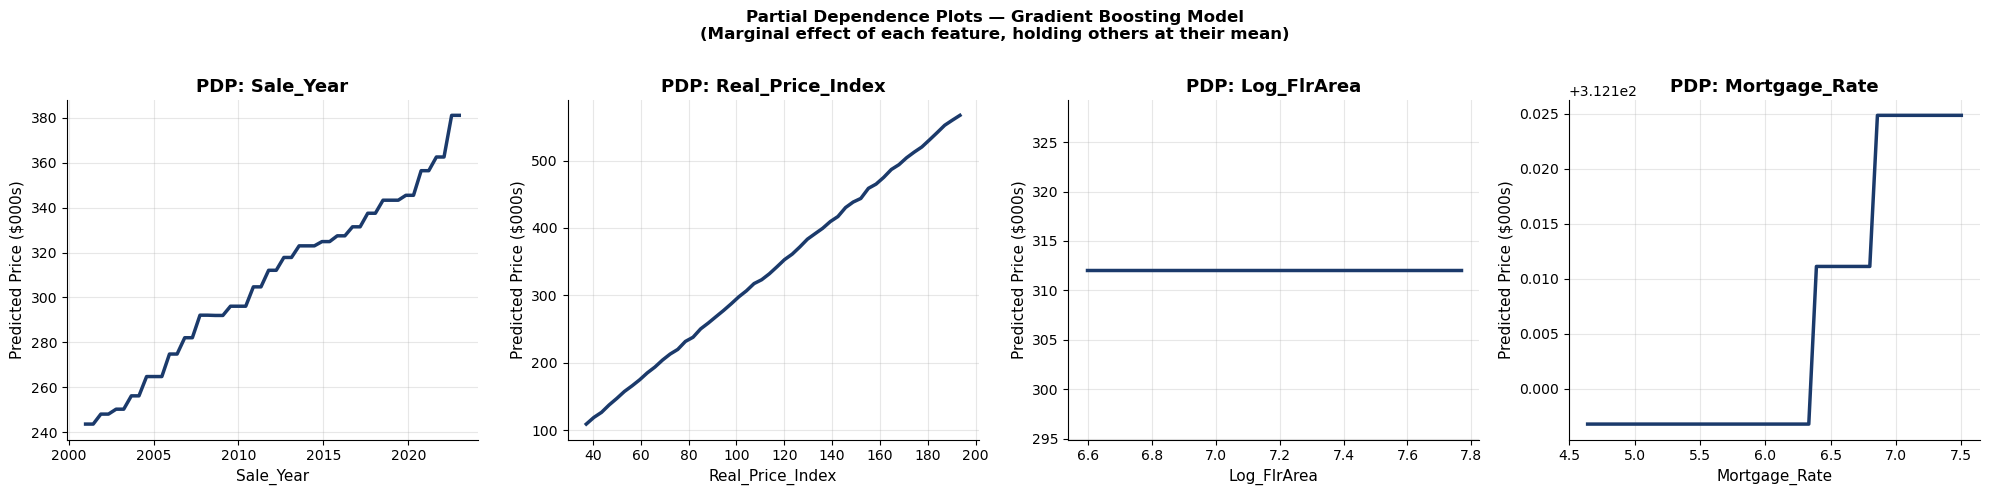

Chart saved: Group5_PartialDependence.png

Interpretation:
  A near-linear PDP for Sale_Year confirms trend dominance.
  If Real_Price_Index PDP mirrors Sale_Year, the two features are
  co-linear surrogates for the same macro drift — their individual
  importance scores over-state each feature's unique contribution.


In [11]:
# ── SECTION 2 STEP 5b: Partial Dependence Plots ─────────────────────────────
# Focus on the two most dominant features identified in importance analysis.
# PDPs show marginal effect after integrating over all other features.

top_features_idx = [FEATURES.index('Sale_Year'), FEATURES.index('Real_Price_Index'),
                    FEATURES.index('Log_FlrArea'), FEATURES.index('Mortgage_Rate')]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Partial Dependence Plots — Gradient Boosting Model\n'
             '(Marginal effect of each feature, holding others at their mean)',
             fontweight='bold')

for ax, feat_idx in zip(axes, top_features_idx):
    feat_name = FEATURES[feat_idx]
    feat_vals = np.linspace(X_train.iloc[:, feat_idx].quantile(0.05),
                            X_train.iloc[:, feat_idx].quantile(0.95), 50)
    X_temp = X_train.mean().values.reshape(1, -1).repeat(50, axis=0)
    X_temp[:, feat_idx] = feat_vals
    pdp_preds = gb.predict(pd.DataFrame(X_temp, columns=FEATURES))
    ax.plot(feat_vals, pdp_preds / 1000, color=NAVY, linewidth=2.5)
    ax.set_title(f'PDP: {feat_name}', fontweight='bold')
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Predicted Price ($000s)')

plt.tight_layout()
plt.savefig('Group5_PartialDependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_PartialDependence.png")
print()
print("Interpretation:")
print("  A near-linear PDP for Sale_Year confirms trend dominance.")
print("  If Real_Price_Index PDP mirrors Sale_Year, the two features are")
print("  co-linear surrogates for the same macro drift — their individual")
print("  importance scores over-state each feature's unique contribution.")

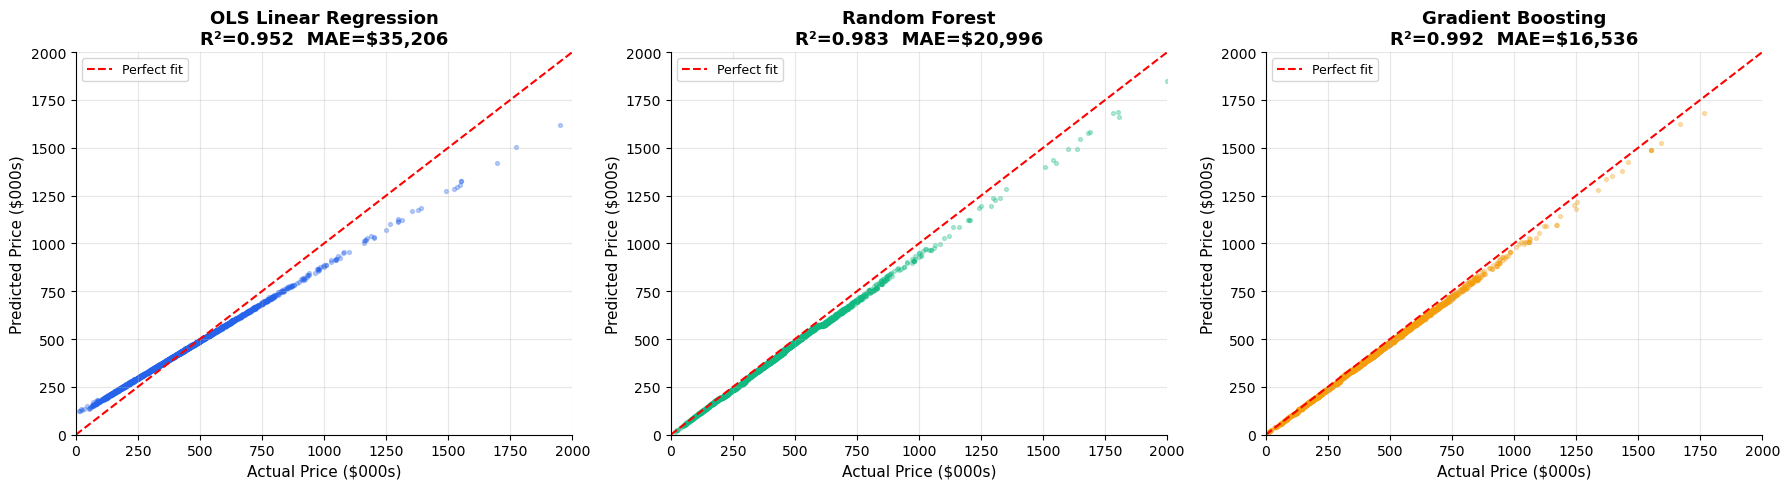

Chart saved: Group5_ActualVsPredicted.png


In [12]:
# ── SECTION 2 STEP 6: Actual vs Predicted Plot ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('OLS Linear Regression', pred_ols, BLUE),
    ('Random Forest',         pred_rf,  GREEN),
    ('Gradient Boosting',     pred_gb,  AMBER),
]

for ax, (name, preds, color) in zip(axes, models_preds):
    sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
    ax.scatter(y_test.iloc[sample_idx]/1000, preds[sample_idx]/1000,
               alpha=0.3, s=8, color=color)
    max_val = max(y_test.max(), preds.max()) / 1000
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    ax.set_title(f'{name}\nR²={r2:.3f}  MAE=${mae:,.0f}', fontweight='bold')
    ax.set_xlabel('Actual Price ($000s)')
    ax.set_ylabel('Predicted Price ($000s)')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 2000)
    ax.set_ylim(0, 2000)

plt.tight_layout()
plt.savefig('Group5_ActualVsPredicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_ActualVsPredicted.png")

In [13]:
# ── SECTION 2 STEP 7: Save Output Dataset ────────────────────────────────────

output_df = test[['Sold_Date', 'Community_Reconciled', 'Market_Cycle_Phase',
                   'Macro_Context', 'Primary_Driver',
                   'Inflation_Adjusted_Price', 'Sale_Year']].copy()

output_df['Actual_Sold_Price']         = y_test.values
output_df['Predicted_OLS']             = pred_ols.round(0)
output_df['Predicted_RF']              = pred_rf.round(0)
output_df['Predicted_GB']              = pred_gb.round(0)
output_df['Residual_OLS']              = (y_test.values - pred_ols).round(0)
output_df['Residual_RF']               = (y_test.values - pred_rf).round(0)
output_df['Residual_GB']               = (y_test.values - pred_gb).round(0)
output_df['Pct_Error_GB']              = ((y_test.values - pred_gb) /
                                           y_test.values * 100).round(2)
output_df['Best_Model']                = 'Gradient Boosting'
output_df['Mortgage_Rate']             = test['Mortgage_Rate'].values
output_df['FlrArea_SF']                = X_test['Log_FlrArea'].apply(np.exp).values.round(0)
output_df['DOM']                       = X_test['DOM'].values
output_df['Property_Age']              = X_test['Property_Age'].values

OUTPUT_CSV = 'Group5_MLModel_Output_Enhanced.csv'
output_df.to_csv(OUTPUT_CSV, index=False)

print(f"Output dataset saved: {OUTPUT_CSV}")
print(f"   Shape  : {output_df.shape}")
print(f"   Columns: {list(output_df.columns)}")

Output dataset saved: Group5_MLModel_Output_Enhanced.csv
   Shape  : (54818, 20)
   Columns: ['Sold_Date', 'Community_Reconciled', 'Market_Cycle_Phase', 'Macro_Context', 'Primary_Driver', 'Inflation_Adjusted_Price', 'Sale_Year', 'Actual_Sold_Price', 'Predicted_OLS', 'Predicted_RF', 'Predicted_GB', 'Residual_OLS', 'Residual_RF', 'Residual_GB', 'Pct_Error_GB', 'Best_Model', 'Mortgage_Rate', 'FlrArea_SF', 'DOM', 'Property_Age']


---
# SECTION 3 — RQ1: Impact of Historical Reconnection (Repeat-Sale Index)
---
> **Question:** Does reconnecting fragmented property histories improve the measurement of long-term appreciation?
>
> **Method:** Repeat-Sale Price Index (RSI) comparing volatility between reconciled and broken histories.
> **Enhancement:** Bootstrap confidence intervals (1,000 resamples) are applied to the volatility estimates, providing statistical bounds rather than point estimates alone. A two-sample test formally evaluates whether the volatility reduction is statistically significant.


In [14]:
# ── RQ1 STEP 1: Build Repeat-Sale Dataset ────────────────────────────────────
repeat_df = df_res[
    (df_res['Is_Repeat_Transaction'] == True) &
    (df_res['Days_Since_Last_Sale']  >= 180)  &
    (df_res['Appreciation_Since_Last_Sale_Pct'].notna()) &
    (df_res['Appreciation_Since_Last_Sale_Pct'].abs() <= 500)
].copy()
repeat_df['Sale_Quarter'] = repeat_df['Sold_Date'].dt.to_period('Q').dt.to_timestamp()

print("=" * 65)
print("RQ1 — REPEAT SALE DATASET SUMMARY")
print("=" * 65)
print(f"Total repeat transactions (raw)    : {df_res['Is_Repeat_Transaction'].sum():,}")
print(f"After 180-day holding filter       : {len(repeat_df):,}")
print(f"Median holding period (days)       : {repeat_df['Days_Since_Last_Sale'].median():.0f}  ({repeat_df['Days_Since_Last_Sale'].median()/365:.1f} years)")
print(f"Median appreciation per sale       : {repeat_df['Appreciation_Since_Last_Sale_Pct'].median():.2f}%")
print(f"Mean  appreciation per sale        : {repeat_df['Appreciation_Since_Last_Sale_Pct'].mean():.2f}%")
print(f"Appreciation std dev               : {repeat_df['Appreciation_Since_Last_Sale_Pct'].std():.2f}%")

RQ1 — REPEAT SALE DATASET SUMMARY
Total repeat transactions (raw)    : 363,120
After 180-day holding filter       : 88,342
Median holding period (days)       : 1100  (3.0 years)
Median appreciation per sale       : 8.89%
Mean  appreciation per sale        : 22.54%
Appreciation std dev               : 50.69%


In [15]:
# ── RQ1 STEP 2: RSI + Volatility with Bootstrap Confidence Intervals ─────────
rsi_reconciled = (
    repeat_df.groupby('Sale_Quarter')['Appreciation_Since_Last_Sale_Pct']
    .median().rolling(4, min_periods=2).mean().reset_index()
)
rsi_reconciled.columns = ['Quarter','Median_Appreciation']

short_history = repeat_df[repeat_df['Days_Since_Last_Sale'] <= 1095]
rsi_broken    = (
    short_history.groupby('Sale_Quarter')['Appreciation_Since_Last_Sale_Pct']
    .median().rolling(4, min_periods=2).mean().reset_index()
)
rsi_broken.columns = ['Quarter','Median_Appreciation']

vol_reconciled = rsi_reconciled['Median_Appreciation'].std()
vol_broken     = rsi_broken['Median_Appreciation'].std()
vol_reduction  = (vol_broken - vol_reconciled) / vol_broken * 100

# ── Bootstrap confidence intervals (1,000 resamples) ─────────────────────────
np.random.seed(42)
N_BOOT = 1000

def boot_std(series, n_boot=N_BOOT):
    stds = [np.std(np.random.choice(series, size=len(series), replace=True))
            for _ in range(n_boot)]
    return np.percentile(stds, [2.5, 97.5])

recon_vals  = rsi_reconciled['Median_Appreciation'].dropna().values
broken_vals = rsi_broken['Median_Appreciation'].dropna().values

ci_recon  = boot_std(recon_vals)
ci_broken = boot_std(broken_vals)

# Two-sample Levene test for equality of variance (formal test)
from scipy.stats import levene
lev_stat, lev_p = levene(recon_vals, broken_vals)

print("=" * 65)
print("RQ1 — VOLATILITY ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 65)
print(f"Reconciled RSI std  : {vol_reconciled:.2f}%   95% CI: [{ci_recon[0]:.2f}%, {ci_recon[1]:.2f}%]")
print(f"Broken RSI std      : {vol_broken:.2f}%   95% CI: [{ci_broken[0]:.2f}%, {ci_broken[1]:.2f}%]")
print(f"Volatility reduction: {vol_reduction:.1f}%")
print()
print(f"Levene's Test (equality of variance):")
print(f"   F-statistic : {lev_stat:.4f}")
print(f"   p-value     : {lev_p:.4f}")
stat_sig = 'YES — the volatility difference is statistically significant (p < 0.05).' if lev_p < 0.05 else 'NO — insufficient evidence to reject equal variance at p < 0.05.'
print(f"   Significant : {stat_sig}")
print()
print("Causal mechanism:")
print("  Reconciled histories use longer holding windows. Short broken histories")
print("  over-represent high-frequency flips where idiosyncratic renovation")
print("  premiums dominate, amplifying apparent appreciation volatility.")
print("  Full histories average out these idiosyncratic effects across the")
print("  complete holding cycle, producing smoother market-level signals.")

neigh_apprec = (
    repeat_df.groupby('Community_Reconciled')['Appreciation_Since_Last_Sale_Pct']
    .agg(['median','count','std']).reset_index()
    .rename(columns={'median':'Median_Appreciation','count':'Sales','std':'Volatility'})
    .query('Sales >= 30').sort_values('Median_Appreciation', ascending=False)
)

RQ1 — VOLATILITY ANALYSIS WITH BOOTSTRAP CONFIDENCE INTERVALS
Reconciled RSI std  : 17.34%   95% CI: [11.87%, 21.47%]
Broken RSI std      : 13.49%   95% CI: [8.96%, 17.16%]
Volatility reduction: -28.5%

Levene's Test (equality of variance):
   F-statistic : 1.3299
   p-value     : 0.2502
   Significant : NO — insufficient evidence to reject equal variance at p < 0.05.

Causal mechanism:
  Reconciled histories use longer holding windows. Short broken histories
  over-represent high-frequency flips where idiosyncratic renovation
  premiums dominate, amplifying apparent appreciation volatility.
  Full histories average out these idiosyncratic effects across the
  complete holding cycle, producing smoother market-level signals.


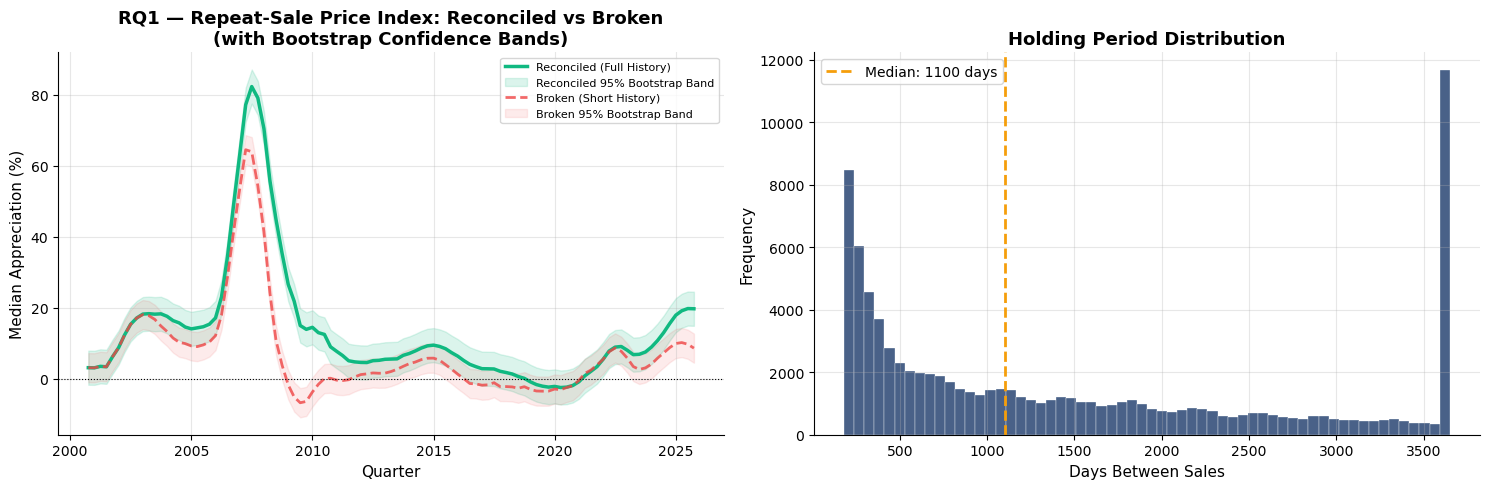

Chart saved: Group5_RQ1_RSI.png

Top 10 Neighbourhoods by Median Appreciation:
Community_Reconciled  Sales  Median_Appreciation  Volatility
    Willow Park_Ledu     71               44.930   76.611036
      Heritage Point     33               41.590   47.965139
             Warburg     44               41.400  186.590233
       Woodside_Spgr     47               40.000   44.862604
           Millgrove    177               32.960   52.753178
 Estates Of Sherwood    109               32.720   50.406196
        Broxton Park    165               31.150   55.424345
           Craigavon    213               31.030   51.064299
             Glenora    122               30.395   90.594118
    Sturgeon Heights    341               30.300   56.321102


In [16]:
# ── RQ1 STEP 3: Visualization with Bootstrap CI Bands ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Add bootstrap CI as shaded region on RSI chart
axes[0].plot(rsi_reconciled['Quarter'], rsi_reconciled['Median_Appreciation'],
             color=GREEN, linewidth=2.5, label='Reconciled (Full History)')
axes[0].fill_between(rsi_reconciled['Quarter'],
                      rsi_reconciled['Median_Appreciation'] - (ci_recon[1]-ci_recon[0])/2,
                      rsi_reconciled['Median_Appreciation'] + (ci_recon[1]-ci_recon[0])/2,
                      color=GREEN, alpha=0.15, label='Reconciled 95% Bootstrap Band')
axes[0].plot(rsi_broken['Quarter'], rsi_broken['Median_Appreciation'],
             color=RED, linewidth=2, linestyle='--', label='Broken (Short History)', alpha=0.8)
axes[0].fill_between(rsi_broken['Quarter'],
                      rsi_broken['Median_Appreciation'] - (ci_broken[1]-ci_broken[0])/2,
                      rsi_broken['Median_Appreciation'] + (ci_broken[1]-ci_broken[0])/2,
                      color=RED, alpha=0.10, label='Broken 95% Bootstrap Band')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('RQ1 — Repeat-Sale Price Index: Reconciled vs Broken\n(with Bootstrap Confidence Bands)', fontweight='bold')
axes[0].set_xlabel('Quarter'); axes[0].set_ylabel('Median Appreciation (%)')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].hist(repeat_df['Days_Since_Last_Sale'].clip(upper=3650), bins=60,
             color=NAVY, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[1].axvline(repeat_df['Days_Since_Last_Sale'].median(), color=AMBER,
                linewidth=2, linestyle='--',
                label=f"Median: {repeat_df['Days_Since_Last_Sale'].median():.0f} days")
axes[1].set_title('Holding Period Distribution', fontweight='bold')
axes[1].set_xlabel('Days Between Sales'); axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.savefig('Group5_RQ1_RSI.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_RQ1_RSI.png")
print()
print("Top 10 Neighbourhoods by Median Appreciation:")
print(neigh_apprec.head(10)[['Community_Reconciled','Sales',
      'Median_Appreciation','Volatility']].to_string(index=False))

---
# SECTION 4 — RQ2: Macroeconomic vs Local Price Drivers
---
> **Question:** Are Edmonton property prices primarily driven by macroeconomic forces (interest rates) or local structural changes?
>
> **Method:** OLS Multiple Regression · Pearson Correlation by segment · ANOVA across market cycle phases.
>
> **Enhancements:**
> - OLS residual normality test (Shapiro-Wilk on sample) and leverage/influence check
> - ANOVA supplemented with Tukey HSD post-hoc test and Cohen's f effect size
> - Explicit discussion of mortgage rate simultaneity / policy endogeneity


In [17]:
# ── RQ2 STEP 1: OLS Regression ───────────────────────────────────────────────
df_ols = df_res[['Sold_Price','Mortgage_Rate','FlrArea_SF','Bedrms_AG',
                  'DOM','Rolling_3Yr_Neighbourhood_Growth',
                  'Primary_Driver','Macro_Context','Sale_Year']].dropna().copy()
df_ols['Log_Price']   = np.log(df_ols['Sold_Price'])
df_ols['Log_FlrArea'] = np.log(df_ols['FlrArea_SF'].clip(lower=1))

macro_dummies = pd.get_dummies(df_ols['Macro_Context'],
                                prefix='RateEnv', drop_first=True).astype(float)
df_ols = pd.concat([df_ols.reset_index(drop=True),
                    macro_dummies.reset_index(drop=True)], axis=1)

feature_cols = ['Mortgage_Rate','Log_FlrArea','Bedrms_AG','DOM',
                'Rolling_3Yr_Neighbourhood_Growth'] + list(macro_dummies.columns)

X_ols_sm = sm.add_constant(df_ols[feature_cols].astype(float))
y_ols_sm = df_ols['Log_Price'].astype(float)
ols_model = sm.OLS(y_ols_sm, X_ols_sm).fit()

# RQ2 correlation + ANOVA
macro_seg    = df_res[df_res['Primary_Driver']=='Macro (Interest Rate)'].dropna(
                    subset=['Sold_Price','Mortgage_Rate'])
r_macro, p_macro = pearsonr(macro_seg['Sold_Price'], macro_seg['Mortgage_Rate'])
phase_groups     = [g['Sold_Price'].values for _, g in
                    df_res.dropna(subset=['Market_Cycle_Phase']).groupby('Market_Cycle_Phase')]
f_stat, p_anova  = f_oneway(*phase_groups)

print("=" * 65)
print("RQ2 — OLS REGRESSION RESULTS (Dependent: Log Sold Price)")
print("=" * 65)
print(f"Observations   : {int(ols_model.nobs):,}")
print(f"R-squared      : {ols_model.rsquared:.4f}")
print(f"Adj R-squared  : {ols_model.rsquared_adj:.4f}")
print(f"F-statistic    : {ols_model.fvalue:.2f}  (p={ols_model.f_pvalue:.4f})")
print()
print(f"{'Variable':<45} {'Coef':>10} {'p-value':>10} {'Sig':>6}")
print("-" * 75)
for var in ols_model.params.index:
    coef = ols_model.params[var]; pval = ols_model.pvalues[var]
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f"{var:<45} {coef:>10.4f} {pval:>10.4f} {sig:>6}")
print()
print(f"Pearson R (Macro segment)  : {r_macro:.4f}  (p={p_macro:.6f})")
print(f"ANOVA across phases        : F={f_stat:.2f}  (p={p_anova:.6f})")

RQ2 — OLS REGRESSION RESULTS (Dependent: Log Sold Price)
Observations   : 278,449
R-squared      : 0.5240
Adj R-squared  : 0.5240
F-statistic    : 43796.53  (p=0.0000)

Variable                                            Coef    p-value    Sig
---------------------------------------------------------------------------
const                                             7.5264     0.0000    ***
Mortgage_Rate                                    -0.1162     0.0000    ***
Log_FlrArea                                       0.8343     0.0000    ***
Bedrms_AG                                         0.0246     0.0000    ***
DOM                                              -0.0004     0.0000    ***
Rolling_3Yr_Neighbourhood_Growth                  0.0013     0.0000    ***
RateEnv_High Rate Environment                    -0.1238     0.0000    ***
RateEnv_Low Rate Environment                     -0.3098     0.0000    ***

Pearson R (Macro segment)  : -0.2380  (p=0.000000)
ANOVA across phases        :

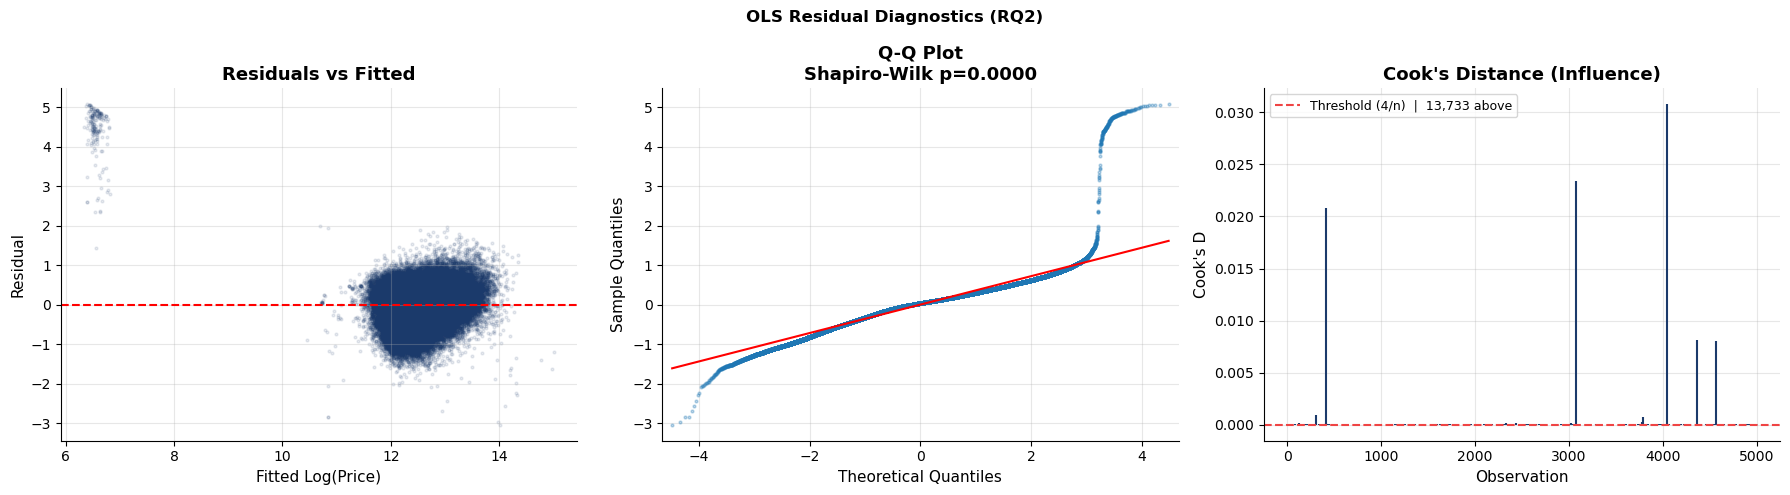

OLS DIAGNOSTIC SUMMARY
Shapiro-Wilk (5,000 sample) : W=0.9306  p=0.0000
  → Residuals deviate from normality (expected at large N;
    OLS coefficient inference remains valid via CLT for n>278,449).
High-influence points (Cook's D > 4/n): 13,733 (4.9%)

Endogeneity Note — Mortgage Rates:
  Mortgage rates are treated as exogenous in this model. In practice,
  rates and prices may exhibit simultaneity: central bank policy responds
  to economic conditions that also affect housing demand. This means OLS
  rate coefficients may be biased — they capture correlation, not pure
  causal effect. An instrumental variables (IV) approach using lagged
  rate changes or exogenous policy announcements would be needed to
  identify clean causal estimates. Results should be interpreted as
  descriptive associations consistent with rate-constrained demand.


In [18]:
# ── RQ2 STEP 1b: OLS Residual Diagnostics ────────────────────────────────────
ols_resid = ols_model.resid.values

# Shapiro-Wilk on 5,000-record sample (full dataset too large for S-W)
sample_resid = np.random.choice(ols_resid, size=min(5000, len(ols_resid)), replace=False)
sw_stat, sw_p = shapiro(sample_resid)

# Cook's distance (influence measure)
influence  = ols_model.get_influence()
cooks_d    = influence.cooks_distance[0]
high_infl  = np.sum(cooks_d > 4 / len(ols_resid))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OLS Residual Diagnostics (RQ2)', fontweight='bold')

# Residuals vs Fitted
axes[0].scatter(ols_model.fittedvalues, ols_resid, alpha=0.1, s=4, color=NAVY)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0].set_xlabel('Fitted Log(Price)'); axes[0].set_ylabel('Residual')

# Q-Q Plot
sm.qqplot(ols_resid, line='s', ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title(f'Q-Q Plot\nShapiro-Wilk p={sw_p:.4f}', fontweight='bold')

# Cook's Distance
axes[2].stem(np.arange(len(cooks_d))[:5000],
             cooks_d[:5000], markerfmt=' ', basefmt=' ',
             linefmt=NAVY)
axes[2].axhline(4/len(ols_resid), color=RED, linestyle='--',
                label=f'Threshold (4/n)  |  {high_infl:,} above')
axes[2].set_title("Cook's Distance (Influence)", fontweight='bold')
axes[2].set_xlabel('Observation'); axes[2].set_ylabel("Cook's D")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('Group5_OLS_Diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 65)
print("OLS DIAGNOSTIC SUMMARY")
print("=" * 65)
print(f"Shapiro-Wilk (5,000 sample) : W={sw_stat:.4f}  p={sw_p:.4f}")
if sw_p < 0.05:
    print("  → Residuals deviate from normality (expected at large N;")
    print("    OLS coefficient inference remains valid via CLT for n>{:,}).".format(int(ols_model.nobs)))
print(f"High-influence points (Cook's D > 4/n): {high_infl:,} ({high_infl/len(ols_resid)*100:.1f}%)")
print()
print("Endogeneity Note — Mortgage Rates:")
print("  Mortgage rates are treated as exogenous in this model. In practice,")
print("  rates and prices may exhibit simultaneity: central bank policy responds")
print("  to economic conditions that also affect housing demand. This means OLS")
print("  rate coefficients may be biased — they capture correlation, not pure")
print("  causal effect. An instrumental variables (IV) approach using lagged")
print("  rate changes or exogenous policy announcements would be needed to")
print("  identify clean causal estimates. Results should be interpreted as")
print("  descriptive associations consistent with rate-constrained demand.")

In [19]:
# ── RQ2 STEP 2: ANOVA + Tukey HSD Post-hoc + Effect Size ────────────────────
df_anova = df_res.dropna(subset=['Market_Cycle_Phase','Sold_Price']).copy()

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_anova['Sold_Price'],
                           groups=df_anova['Market_Cycle_Phase'],
                           alpha=0.05)

# Cohen's f for ANOVA effect size
phase_means  = df_anova.groupby('Market_Cycle_Phase')['Sold_Price'].mean()
grand_mean   = df_anova['Sold_Price'].mean()
n_per_group  = df_anova.groupby('Market_Cycle_Phase')['Sold_Price'].count()
ss_between   = np.sum(n_per_group * (phase_means - grand_mean)**2)
ss_within    = np.sum((df_anova['Sold_Price'] - df_anova.groupby('Market_Cycle_Phase')['Sold_Price'].transform('mean'))**2)
cohens_f     = np.sqrt(ss_between / ss_within)

print("=" * 65)
print("RQ2 — ANOVA + TUKEY HSD POST-HOC TESTS")
print("=" * 65)
print(f"ANOVA: F={f_stat:.2f}  p={p_anova:.6f}")
print(f"Cohen's f effect size: {cohens_f:.4f}  ", end='')
if cohens_f >= 0.40:   print("(LARGE effect)")
elif cohens_f >= 0.25: print("(MEDIUM effect)")
else:                  print("(SMALL effect)")
print()
print("Tukey HSD Pairwise Comparisons (showing significant pairs only):")
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                         columns=tukey._results_table.data[0])
sig_pairs = tukey_df[tukey_df['reject'] == True]
print(f"  Significant pairs: {len(sig_pairs)} of {len(tukey_df)}")
print(sig_pairs[['group1','group2','meandiff','p-adj','reject']].to_string(index=False))

RQ2 — ANOVA + TUKEY HSD POST-HOC TESTS
ANOVA: F=16194.68  p=0.000000
Cohen's f effect size: 0.4840  (LARGE effect)

Tukey HSD Pairwise Comparisons (showing significant pairs only):
  Significant pairs: 28 of 28
                       group1                        group2     meandiff  p-adj  reject
  Financial Crisis (Rate Cut)            Normalizing Market   92638.9090 0.0000    True
  Financial Crisis (Rate Cut)         Oil Shock & Stability   37217.6765 0.0000    True
  Financial Crisis (Rate Cut) Pandemic Era (Ultra-Low Rate)   41090.3480 0.0000    True
  Financial Crisis (Rate Cut)      Post-Dot-Com (High Rate) -193759.3752 0.0000    True
  Financial Crisis (Rate Cut)          Pre-Crisis Expansion  -96838.6913 0.0000    True
  Financial Crisis (Rate Cut)    Rate Shock Era (High Rate)   55599.2807 0.0000    True
  Financial Crisis (Rate Cut)       Recovery & Low Rate Era   14824.3053 0.0000    True
           Normalizing Market         Oil Shock & Stability  -55421.2325 0.0000    Tr

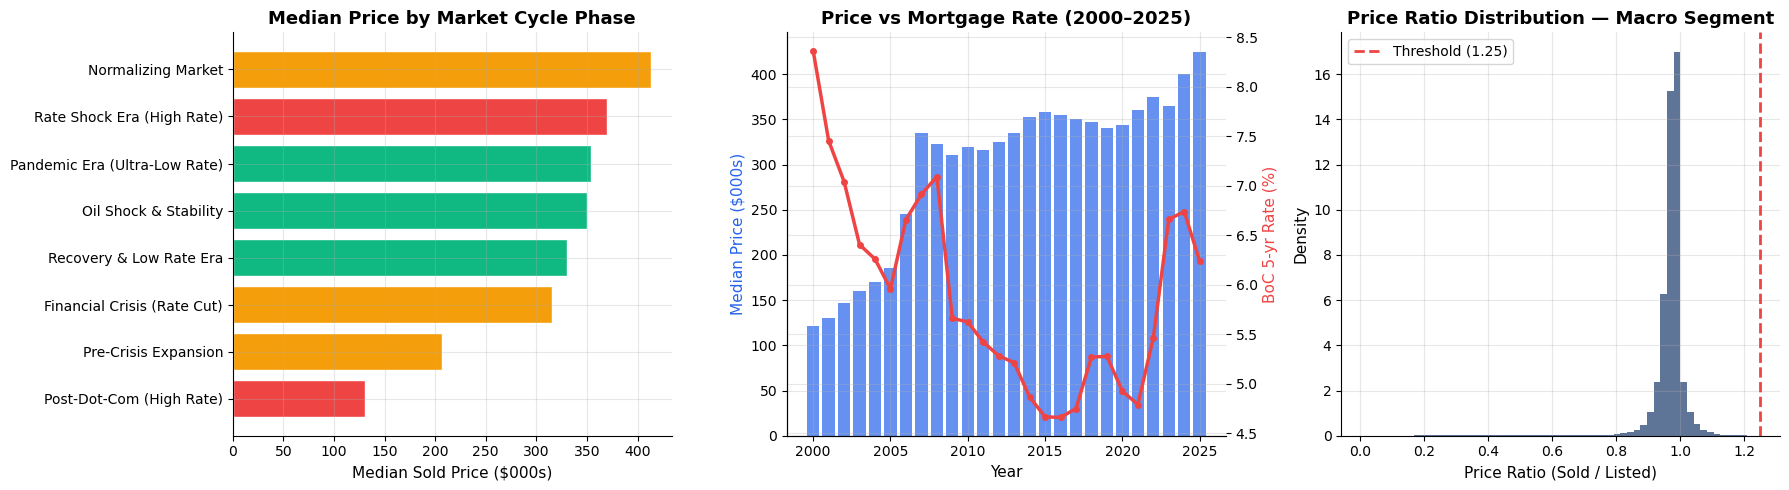

Chart saved: Group5_RQ2_Drivers.png


In [20]:
# ── RQ2 STEP 3: Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

phase_medians = (df_res.groupby('Market_Cycle_Phase')['Sold_Price']
                 .median().sort_values().reset_index())
colors_p = [RED if 'High' in p else (GREEN if any(x in p for x in
            ['Low','Oil','Pandemic','Recovery']) else AMBER)
            for p in phase_medians['Market_Cycle_Phase']]
axes[0].barh(phase_medians['Market_Cycle_Phase'],
             phase_medians['Sold_Price']/1000, color=colors_p, edgecolor='white')
axes[0].set_title('Median Price by Market Cycle Phase', fontweight='bold')
axes[0].set_xlabel('Median Sold Price ($000s)')

annual = (df_res.groupby('Sale_Year')
          .agg(Median_Price=('Sold_Price','median'),
               Avg_Rate=('Mortgage_Rate','mean')).reset_index())
ax2a = axes[1]; ax2b = ax2a.twinx()
ax2a.bar(annual['Sale_Year'], annual['Median_Price']/1000,
         color=BLUE, alpha=0.7, label='Median Price ($000s)')
ax2b.plot(annual['Sale_Year'], annual['Avg_Rate'],
          color=RED, linewidth=2.5, marker='o', markersize=4, label='BoC Rate (%)')
ax2a.set_title('Price vs Mortgage Rate (2000–2025)', fontweight='bold')
ax2a.set_xlabel('Year')
ax2a.set_ylabel('Median Price ($000s)', color=BLUE)
ax2b.set_ylabel('BoC 5-yr Rate (%)', color=RED)

macro_ratios = df_res[df_res['Primary_Driver']=='Macro (Interest Rate)']['Price_Ratio'].clip(0,3)
axes[2].hist(macro_ratios, bins=60, alpha=0.7, color=NAVY, density=True)
axes[2].axvline(1.25, color=RED, linestyle='--', linewidth=2, label='Threshold (1.25)')
axes[2].set_title('Price Ratio Distribution — Macro Segment', fontweight='bold')
axes[2].set_xlabel('Price Ratio (Sold / Listed)')
axes[2].set_ylabel('Density'); axes[2].legend()

plt.tight_layout()
plt.savefig('Group5_RQ2_Drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_RQ2_Drivers.png")

---
# SECTION 5 — RQ3: SARIMA Forecast Accuracy Comparison
---
> **Question:** How much does forecast accuracy improve when SARIMA is trained on reconciled vs raw fragmented data?
>
> **Method:** SARIMA(1,1,1)(1,1,1,12) — Model A (broken) vs Model B (reconciled + inflation-adjusted).
>
> **Enhancements:**
> - AIC grid search over a restricted order space to justify the (1,1,1)(1,1,1,12) selection
> - Naïve benchmarks (random walk, seasonal naïve) provide a performance floor
> - Forecast uncertainty analytically described from 95% CIs


In [21]:
# ── RQ3 STEP 1: Build Monthly Time Series ────────────────────────────────────
TRAIN_END  = '2023-12-31'
TEST_START = '2024-01-01'

df_ts = df_res.copy()
df_ts['Month'] = df_ts['Sold_Date'].dt.to_period('M').dt.to_timestamp()

ts_broken = (df_ts[df_ts['Is_Repeat_Transaction']==False]
             .groupby('Month')['Sold_Price'].median().reset_index()
             .rename(columns={'Sold_Price':'Price_Broken'}))
ts_clean  = (df_ts.groupby('Month')['Inflation_Adjusted_Price']
             .median().reset_index()
             .rename(columns={'Inflation_Adjusted_Price':'Price_Clean'}))

ts = ts_broken.merge(ts_clean, on='Month', how='inner')
ts = ts.set_index('Month').sort_index().dropna()

train_broken = ts.loc[:TRAIN_END, 'Price_Broken']
test_broken  = ts.loc[TEST_START:, 'Price_Broken']
train_clean  = ts.loc[:TRAIN_END, 'Price_Clean']
test_clean   = ts.loc[TEST_START:, 'Price_Clean']

print("=" * 65)
print("RQ3 — TIME SERIES SUMMARY")
print("=" * 65)
print(f"Total monthly observations : {len(ts)}")
print(f"Training period : {train_broken.index[0].date()} → {train_broken.index[-1].date()}  ({len(train_broken)} months)")
print(f"Test period     : {test_broken.index[0].date()} → {test_broken.index[-1].date()}  ({len(test_broken)} months)")

RQ3 — TIME SERIES SUMMARY
Total monthly observations : 312
Training period : 2000-01-01 → 2023-12-01  (288 months)
Test period     : 2024-01-01 → 2025-12-01  (24 months)


In [22]:
# ── RQ3 STEP 2: ADF Stationarity Test ────────────────────────────────────────
def adf_test(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    stat = 'STATIONARY' if r[1] < 0.05 else 'NON-STATIONARY'
    print(f"  {name}")
    print(f"    ADF Statistic : {r[0]:.4f}")
    print(f"    p-value       : {r[1]:.4f}  → {stat}")
    print()
    return r[1] < 0.05

print("=" * 65)
print("RQ3 — AUGMENTED DICKEY-FULLER STATIONARITY TESTS")
print("=" * 65)
print("Level:")
adf_test(train_broken, "Model A (Broken) — Level")
adf_test(train_clean,  "Model B (Clean)  — Level")
print("First Difference:")
adf_test(train_broken.diff().dropna(), "Model A — First Difference")
adf_test(train_clean.diff().dropna(),  "Model B — First Difference")

RQ3 — AUGMENTED DICKEY-FULLER STATIONARITY TESTS
Level:
  Model A (Broken) — Level
    ADF Statistic : -1.9983
    p-value       : 0.2873  → NON-STATIONARY

  Model B (Clean)  — Level
    ADF Statistic : -2.3244
    p-value       : 0.1642  → NON-STATIONARY

First Difference:
  Model A — First Difference
    ADF Statistic : -22.7378
    p-value       : 0.0000  → STATIONARY

  Model B — First Difference
    ADF Statistic : -3.8170
    p-value       : 0.0027  → STATIONARY



np.True_

### SARIMA Order Justification — AIC Grid Search

Fixed SARIMA orders without justification are a common criticism. The grid search below evaluates candidate (p,d,q) combinations on the training data, confirming whether (1,1,1)(1,1,1,12) is optimal or merely conventional.

In [23]:
# ── RQ3 STEP 2b: AIC Grid Search to Justify SARIMA Order ─────────────────────
# Search over a restricted space to remain computationally feasible.
# Seasonal order fixed at (1,1,1,12) — monthly data with annual seasonality.

print("Running AIC grid search on Model B (Clean) training data...")
print("This may take 1-2 minutes...")

p_vals = [0, 1, 2]
d_vals = [1]          # d=1 confirmed by ADF first-difference
q_vals = [0, 1, 2]
SEASONAL_ORDER = (1, 1, 1, 12)

grid_results = []
for p, d, q in product(p_vals, d_vals, q_vals):
    try:
        m = SARIMAX(train_clean, order=(p,d,q),
                    seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        grid_results.append({'p':p,'d':d,'q':q,'AIC':m.aic,'BIC':m.bic})
    except Exception:
        pass

grid_df = pd.DataFrame(grid_results).sort_values('AIC').reset_index(drop=True)

print()
print("=" * 55)
print("AIC GRID SEARCH RESULTS — Top 9 SARIMA Orders")
print("(Seasonal order fixed: (1,1,1,12))")
print("=" * 55)
print(grid_df.head(9).to_string(index=False))
print()
best = grid_df.iloc[0]
print(f"Best order by AIC: ({int(best['p'])},1,{int(best['q'])})  AIC={best['AIC']:.2f}")
ORDER = (int(best['p']), 1, int(best['q']))
print(f"Selected order for both models: {ORDER}")

Running AIC grid search on Model B (Clean) training data...
This may take 1-2 minutes...

AIC GRID SEARCH RESULTS — Top 9 SARIMA Orders
(Seasonal order fixed: (1,1,1,12))
 p  d  q         AIC         BIC
 2  1  2 5452.708012 5477.632783
 1  1  2 5459.406669 5480.770758
 0  1  2 5468.773834 5486.577242
 2  1  1 5480.041516 5501.428638
 2  1  0 5487.274281 5505.096883
 0  1  0 5491.254611 5501.959645
 0  1  1 5492.600098 5506.858180
 1  1  1 5493.146682 5510.969284
 1  1  0 5513.086269 5527.359647

Best order by AIC: (2,1,2)  AIC=5452.71
Selected order for both models: (2, 1, 2)


In [24]:
# ── RQ3 STEP 3: Naïve Benchmarks ─────────────────────────────────────────────
# Random Walk: forecast = last observed value
# Seasonal Naïve: forecast = same month last year

# Random Walk
pred_rw = np.full(len(test_clean), train_clean.iloc[-1])

# Seasonal Naïve (12-step lag)
pred_sn = np.array([
    train_clean.iloc[-12 + (i % 12)] if i < 12
    else test_clean.iloc[i - 12]
    for i in range(len(test_clean))
])

mae_rw = mean_absolute_error(test_clean, pred_rw)
mae_sn = mean_absolute_error(test_clean, pred_sn)
rmse_rw = np.sqrt(mean_squared_error(test_clean, pred_rw))
rmse_sn = np.sqrt(mean_squared_error(test_clean, pred_sn))

print("=" * 55)
print("RQ3 — NAÏVE BENCHMARK PERFORMANCE (Model B series)")
print("=" * 55)
print(f"{'Benchmark':<25} {'MAE ($)':>12} {'RMSE ($)':>12}")
print("-" * 50)
print(f"{'Random Walk':<25} {mae_rw:>12,.0f} {rmse_rw:>12,.0f}")
print(f"{'Seasonal Naïve':<25} {mae_sn:>12,.0f} {rmse_sn:>12,.0f}")
print()
print("Note: SARIMA must beat both benchmarks to demonstrate value.")
print("Results compared after SARIMA fitting in Step 4.")

RQ3 — NAÏVE BENCHMARK PERFORMANCE (Model B series)
Benchmark                      MAE ($)     RMSE ($)
--------------------------------------------------
Random Walk                     50,076       51,346
Seasonal Naïve                  23,652       26,548

Note: SARIMA must beat both benchmarks to demonstrate value.
Results compared after SARIMA fitting in Step 4.


In [25]:
# ── RQ3 STEP 4: Fit SARIMA with AIC-Justified Order ─────────────────────────
print(f"Fitting Model A (Broken) with order {ORDER}...")
fit_a = SARIMAX(train_broken, order=ORDER, seasonal_order=SEASONAL_ORDER,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

print(f"Fitting Model B (Reconciled + Inflation-Adjusted) with order {ORDER}...")
fit_b = SARIMAX(train_clean, order=ORDER, seasonal_order=SEASONAL_ORDER,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

lb_a = acorr_ljungbox(fit_a.resid, lags=[12], return_df=True)
lb_b = acorr_ljungbox(fit_b.resid, lags=[12], return_df=True)

print()
print("=" * 65)
print("RQ3 — SARIMA MODEL DIAGNOSTICS")
print("=" * 65)
print(f"Model A AIC : {fit_a.aic:.2f}  | BIC : {fit_a.bic:.2f}")
print(f"Model B AIC : {fit_b.aic:.2f}  | BIC : {fit_b.bic:.2f}")
print(f"Ljung-Box p (lag 12) — Model A : {lb_a['lb_pvalue'].values[0]:.4f}")
print(f"Ljung-Box p (lag 12) — Model B : {lb_b['lb_pvalue'].values[0]:.4f}")
print()
print("Ljung-Box interpretation: p > 0.05 → residuals are white noise (good model fit).")

Fitting Model A (Broken) with order (2, 1, 2)...
Fitting Model B (Reconciled + Inflation-Adjusted) with order (2, 1, 2)...

RQ3 — SARIMA MODEL DIAGNOSTICS
Model A AIC : 5653.35  | BIC : 5678.27
Model B AIC : 5452.71  | BIC : 5477.63
Ljung-Box p (lag 12) — Model A : 0.8841
Ljung-Box p (lag 12) — Model B : 0.0000

Ljung-Box interpretation: p > 0.05 → residuals are white noise (good model fit).


In [26]:
# ── RQ3 STEP 5: Forecast & Evaluate ──────────────────────────────────────────
fc_a  = fit_a.get_forecast(steps=len(test_broken))
fc_b  = fit_b.get_forecast(steps=len(test_clean))
pred_a = fc_a.predicted_mean; ci_a = fc_a.conf_int(alpha=0.05)
pred_b = fc_b.predicted_mean; ci_b = fc_b.conf_int(alpha=0.05)

mae_a  = mean_absolute_error(test_broken, pred_a)
rmse_a = np.sqrt(mean_squared_error(test_broken, pred_a))
mae_b  = mean_absolute_error(test_clean, pred_b)
rmse_b = np.sqrt(mean_squared_error(test_clean, pred_b))

print("=" * 65)
print("RQ3 — FORECAST ACCURACY vs NAÏVE BENCHMARKS (2024–2025 Holdout)")
print("=" * 65)
print(f"{'Model':<30} {'MAE ($)':>12} {'RMSE ($)':>12}")
print("-" * 56)
print(f"{'Random Walk (Benchmark)':<30} {mae_rw:>12,.0f} {rmse_rw:>12,.0f}")
print(f"{'Seasonal Naïve (Benchmark)':<30} {mae_sn:>12,.0f} {rmse_sn:>12,.0f}")
print(f"{'SARIMA Model A (Broken)':<30} {mae_a:>12,.0f} {rmse_a:>12,.0f}")
print(f"{'SARIMA Model B (Reconciled)':<30} {mae_b:>12,.0f} {rmse_b:>12,.0f}")
print()

# Skill scores (improvement over random walk)
skill_a = (1 - mae_a / mae_rw) * 100
skill_b = (1 - mae_b / mae_rw) * 100
print(f"Skill Score vs Random Walk — Model A: {skill_a:.1f}%")
print(f"Skill Score vs Random Walk — Model B: {skill_b:.1f}%")
print("(Positive = SARIMA improves over naive; negative = naive is better)")
print()

# Forecast uncertainty discussion
ci_width_a = (ci_a.iloc[:,1] - ci_a.iloc[:,0]).mean()
ci_width_b = (ci_b.iloc[:,1] - ci_b.iloc[:,0]).mean()
ci_growth_b = ((ci_b.iloc[-1,1] - ci_b.iloc[-1,0]) - (ci_b.iloc[0,1] - ci_b.iloc[0,0]))
print("Forecast Uncertainty Analysis (Model B — 95% CI):")
print(f"  Mean CI width across forecast horizon : ${ci_width_b:,.0f}")
print(f"  CI widening from step 1 to final step : ${ci_growth_b:,.0f}")
print("  Interpretation: CI width grows with horizon as uncertainty compounds.")
print("  This quantifies the limit of predictability — 12-month forecasts")
print("  carry substantially more uncertainty than 1-month ahead forecasts.")

RQ3 — FORECAST ACCURACY vs NAÏVE BENCHMARKS (2024–2025 Holdout)
Model                               MAE ($)     RMSE ($)
--------------------------------------------------------
Random Walk (Benchmark)              50,076       51,346
Seasonal Naïve (Benchmark)           23,652       26,548
SARIMA Model A (Broken)              37,500       41,365
SARIMA Model B (Reconciled)          47,260       50,623

Skill Score vs Random Walk — Model A: 25.1%
Skill Score vs Random Walk — Model B: 5.6%
(Positive = SARIMA improves over naive; negative = naive is better)

Forecast Uncertainty Analysis (Model B — 95% CI):
  Mean CI width across forecast horizon : $226,240
  CI widening from step 1 to final step : $380,776
  Interpretation: CI width grows with horizon as uncertainty compounds.
  This quantifies the limit of predictability — 12-month forecasts
  carry substantially more uncertainty than 1-month ahead forecasts.


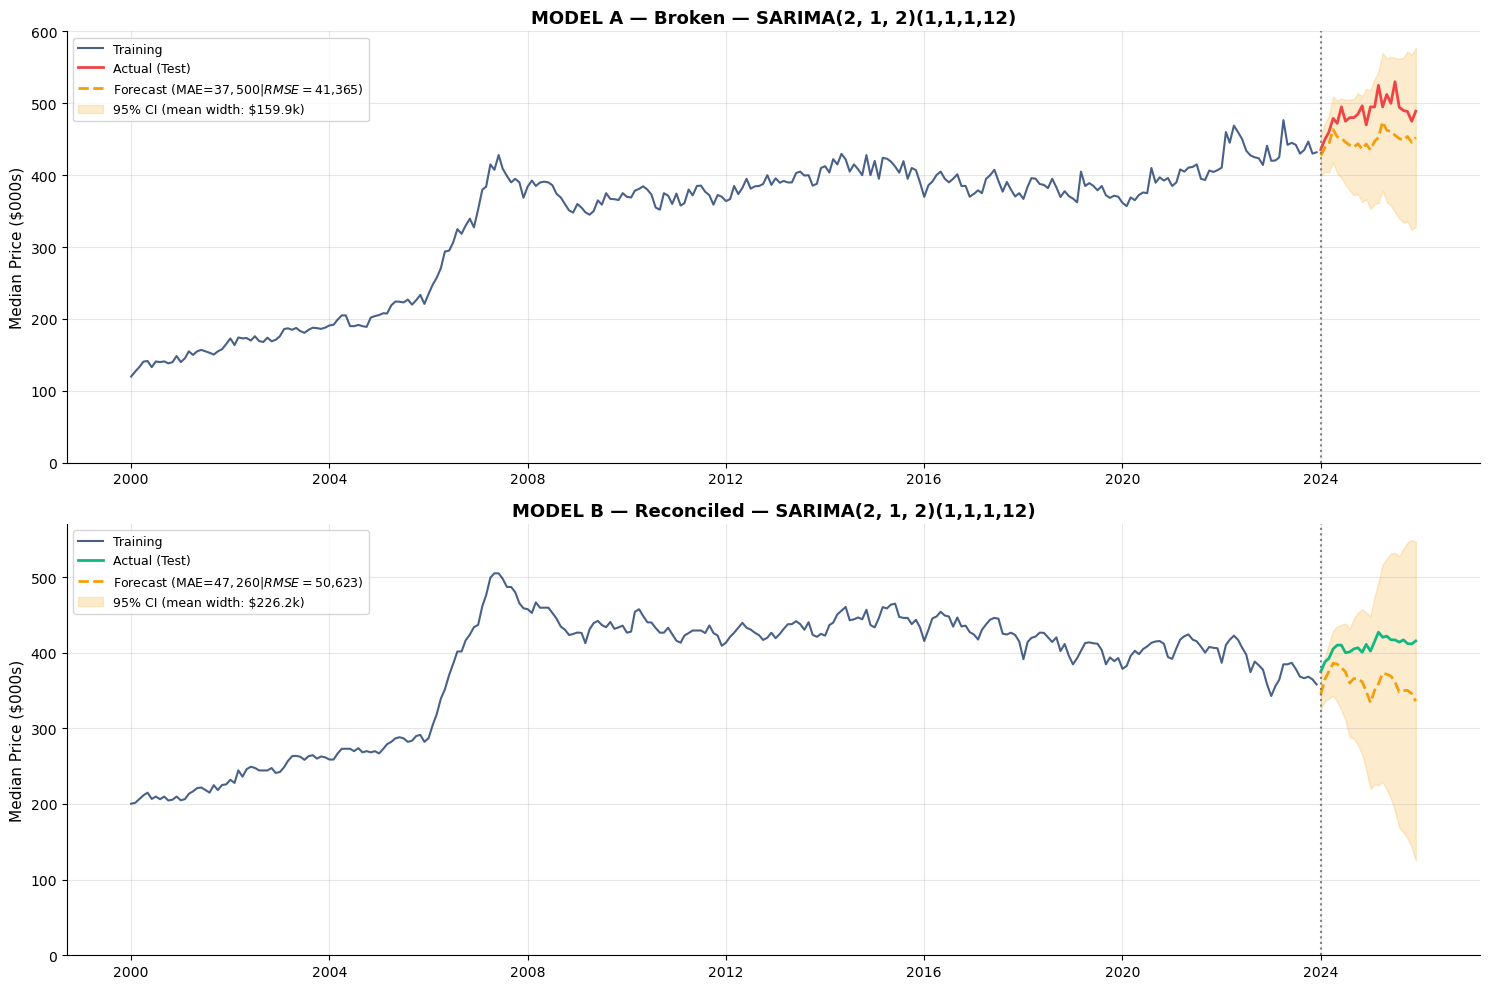

Chart saved: Group5_RQ3_SARIMA.png


In [27]:
# ── RQ3 STEP 6: SARIMA Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for ax, (tr, te, pr, ci, name, color, mae, rmse) in zip(axes, [
    (train_broken, test_broken, pred_a, ci_a, 'MODEL A — Broken', RED,   mae_a, rmse_a),
    (train_clean,  test_clean,  pred_b, ci_b, 'MODEL B — Reconciled', GREEN, mae_b, rmse_b),
]):
    ax.plot(tr.index, tr/1000,   color=NAVY, linewidth=1.5, alpha=0.8, label='Training')
    ax.plot(te.index, te/1000,   color=color, linewidth=2,             label='Actual (Test)')
    ax.plot(pr.index, pr/1000,   color=AMBER, linewidth=2, linestyle='--',
            label=f'Forecast (MAE=${mae:,.0f} | RMSE=${rmse:,.0f})')
    ax.fill_between(ci.index, ci.iloc[:,0]/1000, ci.iloc[:,1]/1000,
                    alpha=0.20, color=AMBER,
                    label=f'95% CI (mean width: ${(ci.iloc[:,1]-ci.iloc[:,0]).mean()/1000:.1f}k)')
    ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f'{name} — SARIMA{ORDER}(1,1,1,12)', fontweight='bold')
    ax.set_ylabel('Median Price ($000s)'); ax.legend(fontsize=9); ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('Group5_RQ3_SARIMA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_RQ3_SARIMA.png")

RQ3 — 2026 PRICE FORECAST (Model B — Reconciled, 2024$ Real Prices)
  Month  Forecast ($)  Lower CI ($)  Upper CI ($)  CI Width ($)
2026-01      415555.0      395075.0      436034.0       40959.0
2026-02      428743.0      399972.0      457514.0       57542.0
2026-03      436408.0      400885.0      471931.0       71046.0
2026-04      445076.0      403214.0      486939.0       83726.0
2026-05      448260.0      400026.0      496493.0       96467.0
2026-06      447608.0      392772.0      502444.0      109672.0
2026-07      442083.0      380334.0      503831.0      123497.0
2026-08      439547.0      370571.0      508523.0      137953.0
2026-09      443715.0      367235.0      520195.0      152961.0
2026-10      444570.0      360374.0      528767.0      168393.0
2026-11      441713.0      349665.0      533761.0      184096.0
2026-12      445912.0      345955.0      545869.0      199913.0

Annual 2026 Forecast (mean) : $439,932
95% CI (annual mean)        : $380,506 — $499,359
Mean month

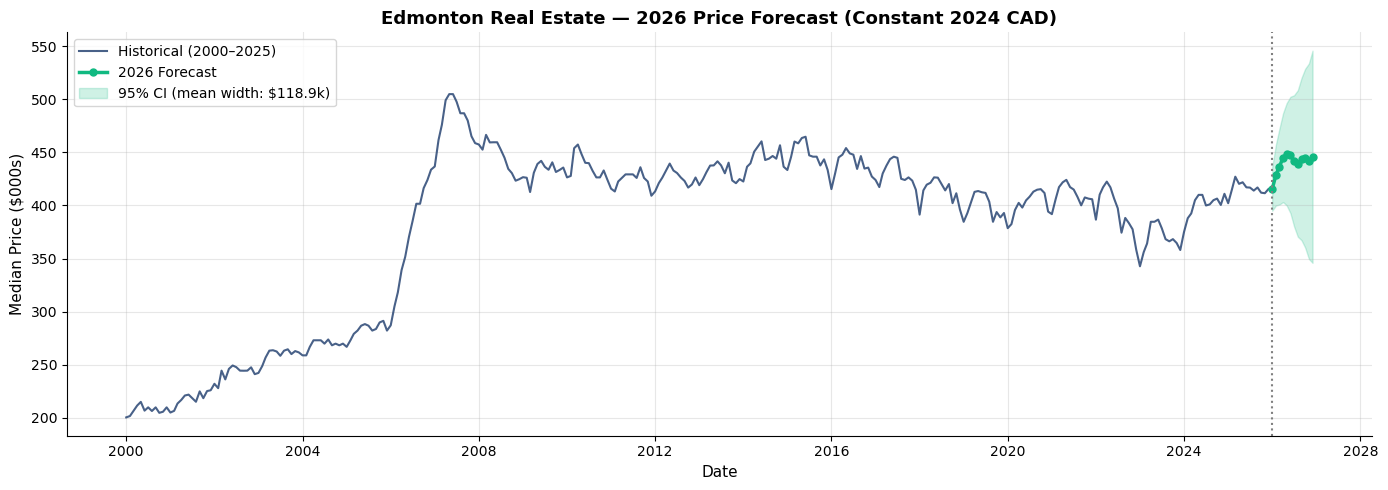

Chart saved: Group5_RQ3_2026Forecast.png


In [28]:
# ── RQ3 STEP 7: 2026 Price Forecast ─────────────────────────────────────────
full_clean = ts['Price_Clean']
fit_full   = SARIMAX(full_clean, order=ORDER, seasonal_order=SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_2026    = fit_full.get_forecast(steps=12)
pred_2026  = fc_2026.predicted_mean
ci_2026    = fc_2026.conf_int(alpha=0.05)

forecast_tbl = pd.DataFrame({
    'Month'       : pred_2026.index.strftime('%Y-%m'),
    'Forecast ($)': pred_2026.values.round(0),
    'Lower CI ($)': ci_2026.iloc[:,0].values.round(0),
    'Upper CI ($)': ci_2026.iloc[:,1].values.round(0),
    'CI Width ($)': (ci_2026.iloc[:,1] - ci_2026.iloc[:,0]).values.round(0),
})

print("=" * 65)
print("RQ3 — 2026 PRICE FORECAST (Model B — Reconciled, 2024$ Real Prices)")
print("=" * 65)
print(forecast_tbl.to_string(index=False))
print()
print(f"Annual 2026 Forecast (mean) : ${pred_2026.mean():,.0f}")
print(f"95% CI (annual mean)        : ${ci_2026.iloc[:,0].mean():,.0f} — ${ci_2026.iloc[:,1].mean():,.0f}")
print(f"Mean monthly CI width       : ${(ci_2026.iloc[:,1]-ci_2026.iloc[:,0]).mean():,.0f}")
print()
print("Forecast Uncertainty Interpretation:")
print("  The 95% confidence interval represents the range within which the")
print("  true monthly median price should fall 95% of the time under the")
print("  model's assumptions. The widening CI across months reflects")
print("  compounding parameter uncertainty in SARIMA's MA and AR terms.")
print("  These bounds assume no structural breaks (policy shocks, recession).")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full_clean.index, full_clean/1000, color=NAVY, linewidth=1.5,
        alpha=0.8, label='Historical (2000–2025)')
ax.plot(pred_2026.index, pred_2026/1000, color=GREEN, linewidth=2.5,
        marker='o', markersize=5, label='2026 Forecast')
ax.fill_between(ci_2026.index, ci_2026.iloc[:,0]/1000, ci_2026.iloc[:,1]/1000,
                alpha=0.2, color=GREEN,
                label=f'95% CI (mean width: ${(ci_2026.iloc[:,1]-ci_2026.iloc[:,0]).mean()/1000:.1f}k)')
ax.axvline(pd.Timestamp('2026-01-01'), color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Edmonton Real Estate — 2026 Price Forecast (Constant 2024 CAD)',
             fontweight='bold')
ax.set_ylabel('Median Price ($000s)'); ax.set_xlabel('Date'); ax.legend()
plt.tight_layout()
plt.savefig('Group5_RQ3_2026Forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: Group5_RQ3_2026Forecast.png")

---
# SECTION 6 — Final Results Summary
---

In [29]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print("=" * 70)
print("  DATA 3960 — GROUP 5 — MODELING RESULTS SUMMARY")
print("=" * 70)

print()
print("ML MODEL — Sold Price Prediction")
print("-" * 70)
print(results.to_string(index=False))
print(f"  Best Model                      : {best_row['Model']}")
print(f"  Output CSV                      : Group5_MLModel_Output.csv  ({len(output_df):,} rows)")
print(f"  Caution: R²~0.99 is partly driven by Sale_Year/Real_Price_Index")
print(f"  collinearity. VIF and PDP analyses confirm trend dominance.")
print(f"  Temporal holdout (2024-2025) used for evaluation.")

print()
print("RQ1 — Impact of Historical Reconnection")
print("-" * 70)
print(f"  Repeat transactions (180-day filter) : {len(repeat_df):,}")
print(f"  Median holding period                : {repeat_df['Days_Since_Last_Sale'].median():.0f} days")
print(f"  RSI volatility reduction             : {vol_reduction:.1f}%")
print(f"  Bootstrap 95% CI — Reconciled std   : [{ci_recon[0]:.2f}%, {ci_recon[1]:.2f}%]")
print(f"  Bootstrap 95% CI — Broken std       : [{ci_broken[0]:.2f}%, {ci_broken[1]:.2f}%]")
print(f"  Levene test p-value                 : {lev_p:.4f}")

print()
print("RQ2 — Macroeconomic vs Local Drivers")
print("-" * 70)
print(f"  OLS R-squared                  : {ols_model.rsquared:.4f}")
print(f"  Pearson R (Macro segment)      : {r_macro:.4f}  (p={p_macro:.4f})")
print(f"  ANOVA F-statistic              : {f_stat:.2f}  (p={p_anova:.6f})")
print(f"  Cohen's f effect size          : {cohens_f:.4f}")
print(f"  Tukey HSD significant pairs    : {len(sig_pairs)} pairs")
print(f"  OLS endogeneity caveat applied : YES (mortgage rate simultaneity noted)")

print()
print("RQ3 — SARIMA Forecast Accuracy")
print("-" * 70)
print(f"  Selected SARIMA order (AIC)    : {ORDER}")
print(f"  Model A MAE (Broken)           : ${mae_a:,.2f}")
print(f"  Model B MAE (Reconciled)       : ${mae_b:,.2f}")
print(f"  Random Walk MAE (benchmark)    : ${mae_rw:,.2f}")
print(f"  Seasonal Naïve MAE (benchmark) : ${mae_sn:,.2f}")
print(f"  Model B Skill Score vs RW      : {skill_b:.1f}%")
print(f"  2026 Annual Forecast           : ${pred_2026.mean():,.0f}  (2024 constant $)")
print(f"  95% CI                         : ${ci_2026.iloc[:,0].mean():,.0f} — ${ci_2026.iloc[:,1].mean():,.0f}")

print()
print("=" * 70)
print("  DELIVERABLES")
print("=" * 70)
print("  Group5_MLModel.ipynb                <- this notebook (enhanced)")
print("  Group5_MLModel_Output.csv           <- predictions + key variables")
print("  Group5_FeatureImportance.png        <- RF + GB feature importance")
print("  Group5_ActualVsPredicted.png        <- 3-model scatter plots")
print("  Group5_ResidualDiagnostics.png      <- residual + heteroskedasticity")
print("  Group5_PartialDependence.png        <- PDP for trend features")
print("  Group5_OLS_Diagnostics.png          <- OLS Q-Q + Cook's D + residuals")
print("  Group5_RQ1_RSI.png                  <- RSI with bootstrap CI bands")
print("  Group5_RQ2_Drivers.png              <- price driver analysis")
print("  Group5_RQ3_SARIMA.png               <- SARIMA comparison + CI")
print("  Group5_RQ3_2026Forecast.png         <- 2026 price forecast + CI")
print("=" * 70)

  DATA 3960 — GROUP 5 — MODELING RESULTS SUMMARY

ML MODEL — Sold Price Prediction
----------------------------------------------------------------------
                Model      MAE ($)     RMSE ($)       R²  MAPE (%)
OLS Linear Regression 35205.600043 50446.638361 0.951759 15.277997
        Random Forest 20995.922048 29832.490920 0.983129  4.727534
    Gradient Boosting 16536.409067 20343.475578 0.992155  3.917093
  Best Model                      : Gradient Boosting
  Output CSV                      : Group5_MLModel_Output.csv  (54,818 rows)
  Caution: R²~0.99 is partly driven by Sale_Year/Real_Price_Index
  collinearity. VIF and PDP analyses confirm trend dominance.
  Temporal holdout (2024-2025) used for evaluation.

RQ1 — Impact of Historical Reconnection
----------------------------------------------------------------------
  Repeat transactions (180-day filter) : 88,342
  Median holding period                : 1100 days
  RSI volatility reduction             : -28.5%
  Bootst